<a href="https://colab.research.google.com/github/yangyuwang/wikiart_metadata/blob/main/wikipedia_demographic_extract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load wikipedia

In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import os
import re
from tqdm import tqdm

artist_wikipedia_text_example = []

path = '/content/drive/My Drive/artist_wikipedia_content/'

target_name = [re.sub(r".txt", "", target) for target in os.listdir(path)]

for file in tqdm(os.listdir(path)):
  with open(path + file, "r") as f:
    artist_wikipedia_text_example.append(re.sub("\n", "", f.read()))

100%|██████████| 2752/2752 [00:05<00:00, 539.18it/s]


# OPENAI settings

In [5]:
pip install --upgrade openai

  Using cached openai-2.6.1-py3-none-any.whl.metadata (29 kB)
Using cached openai-2.6.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: openai
    Found existing installation: openai 0.28.0
    Uninstalling openai-0.28.0:
      Successfully uninstalled openai-0.28.0


In [6]:
import getpass
OPENAI_API_KEY = getpass.getpass()

··········


# Structured Outputs

In [60]:
from typing import List, Optional
from pydantic import BaseModel, create_model
from enum import Enum
import re

class Education(BaseModel):
    year: Optional[int] = None  # Year of graduation
    school: str  # School of education.
    degree: Optional[str] = None  # Degree earned.

class Affiliation(BaseModel):
    group: str  # full name of the group.
    type_of_group: Optional[str] = None  # The type of the group.
    start_year: Optional[int] = None  # Year of affiliation start.
    end_year: Optional[int] = None  # Year of affiliation end.

class Residence(BaseModel):
    location: str  # Location of residence.
    start_year: Optional[int] = None  # Year of residence start.
    end_year: Optional[int] = None  # Year of residence end.

class Visit(BaseModel):
    location: str  # Location visited.
    start_year: Optional[int] = None  # Year of visit start.
    end_year: Optional[int] = None  # Year of visit end.

class Religion(BaseModel):
    religion: str  # full name of the religion believed.
    start_year: Optional[int] = None  # Year of starting believing.
    end_year: Optional[int] = None  # Year of ending believing.

class Interaction(BaseModel):
    # index into the name list you give in the prompt
    name: str
    year: int = None # Year of first-time interaction.
    location: Optional[str] = None
    role_ego: Optional[str] = None
    role_alter: Optional[str] = None

class Artist(BaseModel):
    # identify the artist
    name: str

    # flattened life info
    birth_year: Optional[int] = None
    birth_place: Optional[str] = None     # "Florence, Italy"
    death_year: Optional[int] = None
    death_place: Optional[str] = None

    # simple flat metadata
    nationality: Optional[str] = None
    ethnicity: Optional[str] = None
    gender: str
    languages_spoken: Optional[List[str]] = None    # ["Italian", "French"]

    # flattened education / affiliation / religion / moves
    # just text lines so GPT doesn’t have to nest
    education: Optional[List[Education]] = None
    affiliations: Optional[List[Affiliation]] = None
    religion: Optional[List[Religion]] = None

    residences: Optional[List[Residence]] = None
    visits: Optional[List[Visit]] = None

    # constrained interactions
    interactions: Optional[List[Interaction]] = None



In [68]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

name_table = "\n".join(target_name)

def extract_demographics_structured(text: str, name_table: list[str]):
    # make a numbered list for the prompt

    resp = client.beta.chat.completions.parse(
        model="gpt-4.1-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You extract demographic info about an artist.\n"
                    "All information extracted should be in American English.\n"
                    "For gender, you MUST return 'female', 'male', or 'non-binary'.\n"
                    "For interactions, you MUST return the name of the artist "
                    "from the list below and the year of first-time interaction "
                    "(which could be a guess from artists' experiences).\n"
                    "AVAILABLE ARTISTS:\n" + name_table
                ),
            },
            {"role": "user", "content": text},
        ],
        response_format=Artist,
    )
    information = resp.choices[0].message.parsed
    return information

In [69]:
len(artist_wikipedia_text_example)

2752

In [70]:
import json
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

def process_item(i):
    # Process a single item and return a tuple of (name, processed info as dict)
    # If processing fails, you might want to catch exceptions here
    information = extract_demographics_structured(artist_wikipedia_text_example[i],name_table)
    return target_name[i], information.model_dump()

# Number of workers can be set based on Colab's CPUs (usually 2-4 cores)
n_workers = 4

information_dict_n = {}

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    # Submit tasks for all items
    futures = {executor.submit(process_item, i): i for i in range(len(artist_wikipedia_text_example))}

    for future in tqdm(as_completed(futures), total=len(futures)):
        try:
            name, info = future.result()
            information_dict_n[name] = info
        except Exception as e:
            print(f"Error processing item {futures[future]}: {e}")

# Save the dictionary as a JSON file
with open("/content/drive/My Drive/artist_data/demographic_information_modified.json", "w", encoding="utf-8") as file:
    json.dump(information_dict_n, file, indent=2, ensure_ascii=False)

print("Processing complete and file saved.")


100%|██████████| 2752/2752 [1:07:51<00:00,  1.48s/it]


Processing complete and file saved.


In [71]:
len(information_dict_n)

2752

In [72]:
genders = []
nationalities = []
interaction_targets = []

for slug, a in information_dict_n.items():
    # gender
    g = a.get("gender")
    if g:
        genders.append(g)

    # nationality
    nat = a.get("nationality")
    if nat:
        nationalities.append(nat)

    # interactions
    for it in a.get("interactions") or []:
        tgt = it.get("name")
        if tgt:
            interaction_targets.append(tgt)

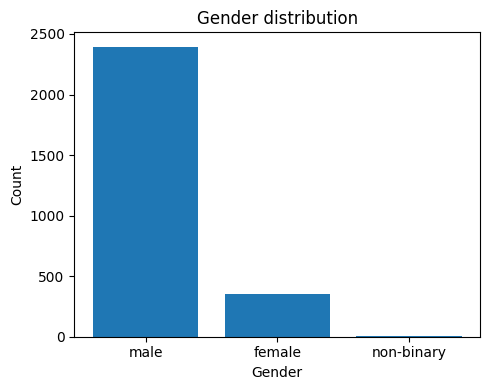

In [74]:
import matplotlib.pyplot as plt
from collections import Counter

gender_counts = Counter(genders)

plt.figure(figsize=(5, 4))
plt.bar(gender_counts.keys(), gender_counts.values())
plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

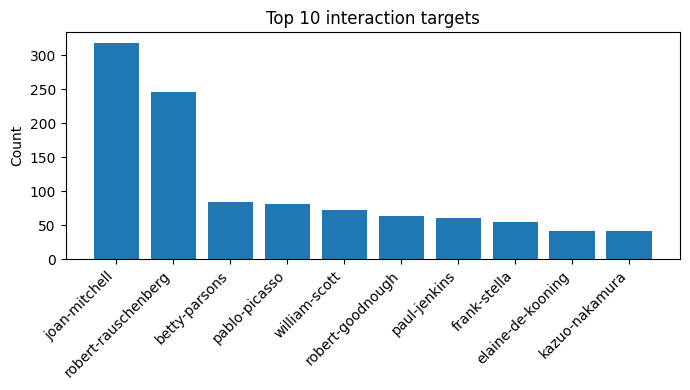

In [75]:
inter_counts = Counter(interaction_targets)
top10_inter = inter_counts.most_common(10)

if top10_inter:
    labels, values = zip(*top10_inter)
else:
    labels, values = [], []

plt.figure(figsize=(7, 4))
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=45, ha="right")
plt.title("Top 10 interaction targets")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

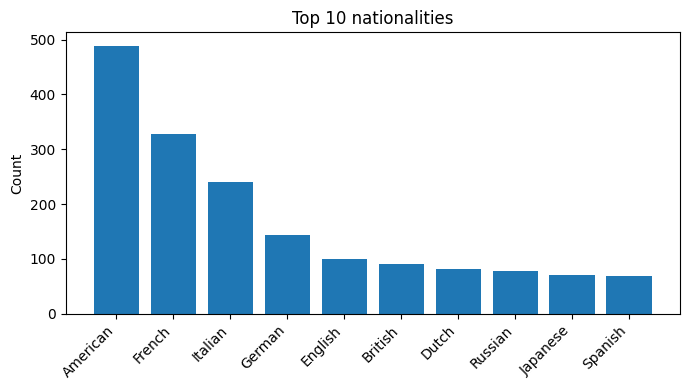

In [76]:
nat_counts = Counter(nationalities)
top10_nat = nat_counts.most_common(10)

if top10_nat:
    nat_labels, nat_values = zip(*top10_nat)
else:
    nat_labels, nat_values = [], []

plt.figure(figsize=(7, 4))
plt.bar(range(len(nat_values)), nat_values)
plt.xticks(range(len(nat_values)), nat_labels, rotation=45, ha="right")
plt.title("Top 10 nationalities")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Structured Outputs (Old version)

In [ ]:
from pydantic import BaseModel
from openai import OpenAI
from typing import List
from typing import Optional

class Location(BaseModel):
    city_full: str  # full name of the city.
    region_full: Optional[str] = None  # full name of the region (could be state, province, or other administrative division).
    country_full: Optional[str] = None  # full name of the country.

class Birth(BaseModel):
    year: Optional[int] = None  # Year of birth.
    location: Optional[Location] = None  # Location of birth.

class Death(BaseModel):
    year: Optional[int] = None  # Year of death.
    location: Optional[Location] = None  # Location of death.

class Education(BaseModel):
    year: Optional[int] = None  # Year of education.
    school: Optional[str] = None  # School of education.
    degree: Optional[str] = None  # Degree earned.

class Affiliation(BaseModel):
    group: str  # full name of the group.
    type_of_group: Optional[str] = None  # The type of the group.
    start_year: Optional[int] = None  # Year of affiliation start.
    end_year: Optional[int] = None  # Year of affiliation end.

class Residence(BaseModel):
    location: Location  # Location of residence.
    start_year: Optional[int] = None  # Year of residence start.
    end_year: Optional[int] = None  # Year of residence end.

class Visit(BaseModel):
    location: Location  # Location visited.
    start_year: Optional[int] = None  # Year of visit start.
    end_year: Optional[int] = None  # Year of visit end.

class Religion(BaseModel):
    religion: str  # full name of the religion believed.
    start_year: Optional[int] = None  # Year of starting believing.
    end_year: Optional[int] = None  # Year of ending believing.

class Interaction(BaseModel):
    name: str  # Name of who the artist interacted with.
    role_ego: Optional[str] = None  # the artist's role in the interaction.
    role_alter: Optional[str] = None  # others' role in the interaction.
    year: Optional[int] = None  # Year of interaction.
    location: Optional[Location] = None  # Location of interaction, if any.

class Artist(BaseModel):
    birth: Birth
    death: Death
    education: List[Education] = None  # Education of the artist.
    nationality: Optional[str] = None  # Nationality of the artist.
    ethnicity: Optional[str] = None  # Ethnicity of the artist.
    languages_spoken: Optional[List[str]] = None  # Languages spoken by the artist.
    affiliations: Optional[List[Affiliation]] = None  # Groups the artist is affiliated with.
    religion: Optional[List[Religion]] = None  # Religion of the artist.
    gender: str  # Gender of the artist.
    residences: Optional[List[Residence]] = None  # Residences of the artist.
    visits: Optional[List[Visit]] = None  # Cities visited by the artist.
    interactions: Optional[List[Interaction]] = None  # Interactions with other artists.

    #mixing: mechanistic analysis
    #improve our prediction
    #prediction: if artists drew next year


In [ ]:
client = OpenAI(api_key=OPENAI_API_KEY)

def extract_demographics_structured(text):
    completion = client.beta.chat.completions.parse(
        model="o3-mini-2025-01-31", #"gpt-4o-mini-2024-07-18",
        messages=[
            {"role": "system", "content": "Extract the demographic information from artist wikipedia."},
            {"role": "user", "content": f"{text}"},
        ],
        response_format=Artist,
    )

    information = completion.choices[0].message.parsed
    return information

In [ ]:
information_dict = {}


In [ ]:
import json
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

def process_item(i):
    # Process a single item and return a tuple of (name, processed info as dict)
    # If processing fails, you might want to catch exceptions here
    information = extract_demographics_structured(artist_wikipedia_text_example[i])
    return target_name[i], information.model_dump()

# Number of workers can be set based on Colab's CPUs (usually 2-4 cores)
n_workers = 4

information_dict_n = {}

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    # Submit tasks for all items
    futures = {executor.submit(process_item, i): i for i in range(len(artist_wikipedia_text_example))}

    for future in tqdm(as_completed(futures), total=len(futures)):
        try:
            name, info = future.result()
            information_dict_n[name] = info
        except Exception as e:
            print(f"Error processing item {futures[future]}: {e}")

# Save the dictionary as a JSON file
with open("/content/drive/My Drive/artist_data/demographic_information.json", "w", encoding="utf-8") as file:
    json.dump(information_dict_n, file, indent=2, ensure_ascii=False)

print("Processing complete and file saved.")


100%|██████████| 2752/2752 [3:23:01<00:00,  4.43s/it]


Processing complete and file saved.


In [ ]:
information_dict_n['a-y-jackson']

{'birth': {'year': 1882,
  'location': {'city_full': 'Montreal',
   'region_full': 'Quebec',
   'country_full': 'Canada'}},
 'death': {'year': 1974,
  'location': {'city_full': 'Toronto',
   'region_full': 'Ontario',
   'country_full': 'Canada'}},
 'education': [{'year': 1902,
   'school': 'Art Association of Montreal',
   'degree': None},
  {'year': 1907, 'school': 'Académie Julian, Paris', 'degree': None},
  {'year': None, 'school': 'Chicago Art Institute', 'degree': None}],
 'nationality': 'Canadian',
 'ethnicity': None,
 'languages_spoken': ['English', 'French'],
 'affiliations': [{'group': 'Group of Seven',
   'type_of_group': 'Artists collective',
   'start_year': 1919,
   'end_year': None},
  {'group': 'Beaver Hall Group',
   'type_of_group': 'Artists group',
   'start_year': 1920,
   'end_year': None},
  {'group': 'Canadian Group of Painters',
   'type_of_group': 'Artists group',
   'start_year': 1933,
   'end_year': None}],
 'religion': None,
 'gender': 'Male',
 'residences': 

Error visualizing residences: 'NoneType' object is not iterable
Error visualizing visits: 'NoneType' object is not iterable
Error visualizing interactions: 'NoneType' object is not iterable
Error visualizing affiliations: 'NoneType' object is not iterable


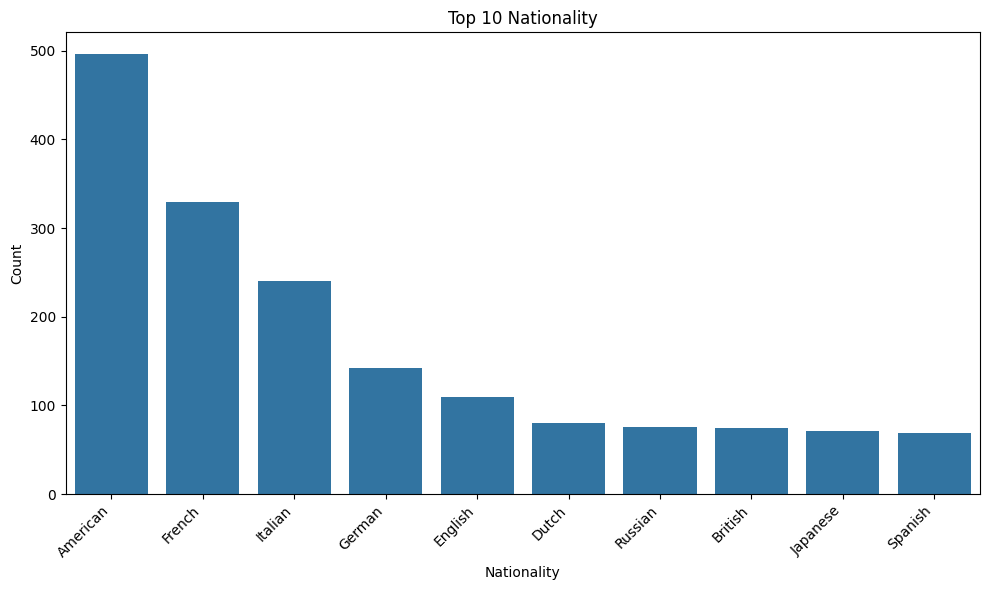

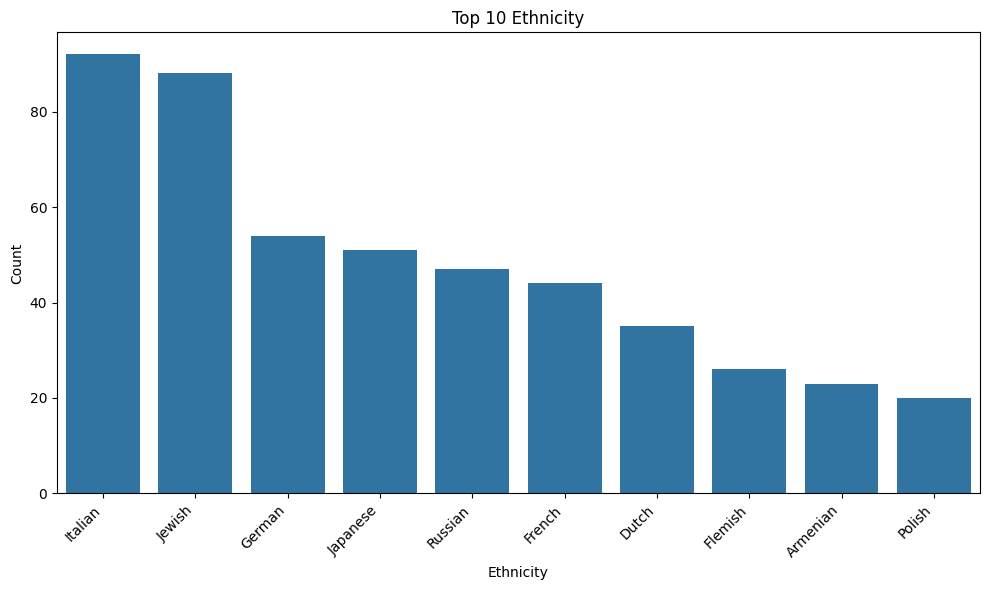

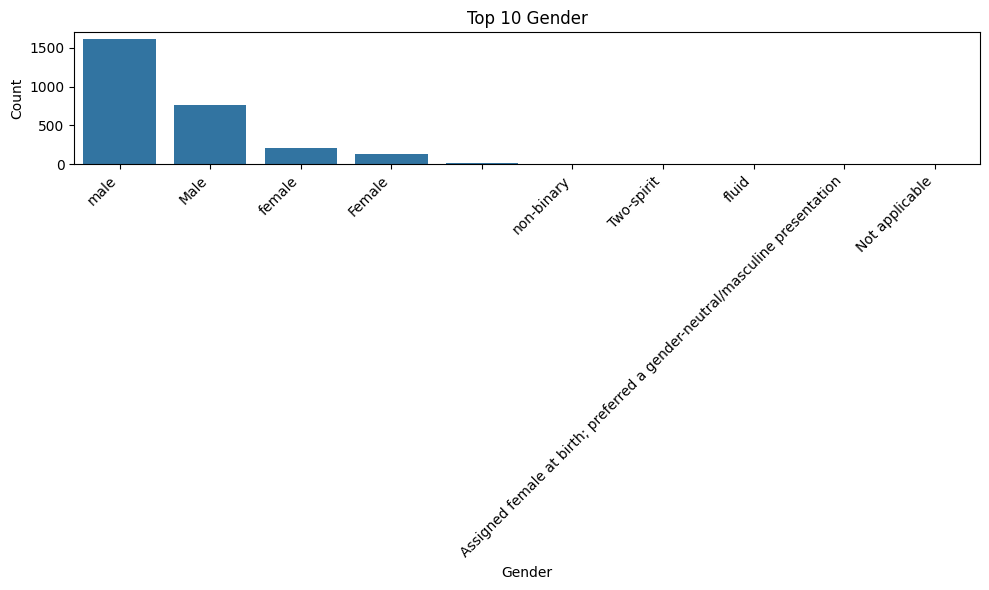

In [ ]:
# prompt: visualize the top ten categories in each variable in information_dict_n

import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Load the JSON data
with open('/content/drive/My Drive/artist_data/demographic_information.json', 'r') as f:
    information_dict_n = json.load(f)

def visualize_top_categories(data, variable, top_n=10):
    """Visualizes the top N categories for a given variable."""

    try:
        # Extract the categories and their counts
        if variable == "residences":
            categories = [item.get("location", {}).get("city_full", "N/A") for artist_data in data.values() for item in artist_data.get("residences", []) if item]
        elif variable == "visits":
            categories = [item.get("location", {}).get("city_full", "N/A") for artist_data in data.values() for item in artist_data.get("visits", []) if item]
        elif variable == "interactions":
            categories = [item.get("name", "N/A") for artist_data in data.values() for item in artist_data.get("interactions", []) if item]
        elif variable == "affiliations":
            categories = [item.get("group", "N/A") for artist_data in data.values() for item in artist_data.get("affiliations", []) if item]
        else: #nationality, ethnicity, gender
            categories = [artist_data.get(variable, "N/A") for artist_data in data.values()]

        category_counts = pd.Series(categories).value_counts().head(top_n)

        # Create the bar plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x=category_counts.index, y=category_counts.values)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Top {top_n} {variable.capitalize()}')
        plt.xlabel(variable.capitalize())
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error visualizing {variable}: {e}")


# Example usage for residences, visits, interactions, affiliations, nationality, ethnicity, gender
visualize_top_categories(information_dict_n, "residences")
visualize_top_categories(information_dict_n, "visits")
visualize_top_categories(information_dict_n, "interactions")
visualize_top_categories(information_dict_n, "affiliations")
visualize_top_categories(information_dict_n, "nationality")
visualize_top_categories(information_dict_n, "ethnicity")
visualize_top_categories(information_dict_n, "gender")
